In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Enable aggressive, automatic tab completion for the current notebook session
%config IPCompleter.greedy=True

In [2]:
dataset_id = "ji8i-4anb"

url = f"https://www.datos.gov.co/resource/{dataset_id}.csv?$limit=500000"

print("Descargando datos desde datos.gov.co...")

df = pd.read_csv(url)

df.info()

Descargando datos desde datos.gov.co...
<class 'pandas.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ano                          462 non-null    int64  
 1   c_digo_departamento          462 non-null    int64  
 2   departamento                 462 non-null    str    
 3   poblacion_5_16               462 non-null    int64  
 4   tasa_matriculacion_5_16      462 non-null    float64
 5   cobertura_neta               462 non-null    float64
 6   cobertura_neta_transicion    462 non-null    float64
 7   cobertura_neta_primaria      462 non-null    float64
 8   cobertura_neta_secundaria    462 non-null    float64
 9   cobertura_neta_media         462 non-null    float64
 10  cobertura_bruta              462 non-null    float64
 11  cobertura_bruta_transicion   462 non-null    float64
 12  cobertura_bruta_primaria     462 non-null    floa

In [3]:
df.isnull().sum()

ano                              0
c_digo_departamento              0
departamento                     0
poblacion_5_16                   0
tasa_matriculacion_5_16          0
cobertura_neta                   0
cobertura_neta_transicion        0
cobertura_neta_primaria          0
cobertura_neta_secundaria        0
cobertura_neta_media             0
cobertura_bruta                  0
cobertura_bruta_transicion       0
cobertura_bruta_primaria         0
cobertura_bruta_secundaria       0
cobertura_bruta_media            0
tamano_promedio_grupo          231
sedes_conectadas_a_internet    231
desercion                        0
desercion_transicion             1
desercion_primaria               0
desercion_secundaria             0
desercion_media                  0
aprobacion                       0
aprobacion_transicion            0
aprobacion_primaria              0
aprobacion_secundaria            0
aprobacion_media                 0
reprobacion                      0
reprobacion_transici

In [8]:
df.shape

(462, 37)

In [5]:
df[df['tamano_promedio_grupo'].isnull()]

,ano,c_digo_departamento,departamento,poblacion_5_16,tasa_matriculacion_5_16,cobertura_neta,cobertura_neta_transicion,cobertura_neta_primaria,cobertura_neta_secundaria,cobertura_neta_media,...,reprobacion,reprobacion_transicion,reprobacion_primaria,reprobacion_secundaria,reprobacion_media,repitencia,repitencia_transicion,repitencia_primaria,repitencia_secundaria,repitencia_media
231,2018,5,Antioquia,1147598,84.72,94.11,67.98,91.89,81.29,43.83,...,6.91,0.19,91.00,10.05,5.41,3.13,0.19,3.14,4.22,1.29
232,2018,8,Atlántico,521630,92.53,91.34,61.54,89.02,76.55,49.27,...,4.88,1.92,94.11,6.60,3.46,0.74,1.92,0.78,0.85,0.27
233,2018,11,"Bogotá, D.C.",1179282,78.71,96.51,70.65,97.81,85.97,56.01,...,0.33,0.00,98.65,0.07,2.15,0.33,0.00,0.24,0.57,0.21
234,2018,13,Bolívar,455784,92.71,98.60,69.74,97.25,79.38,44.17,...,6.93,0.86,91.26,9.43,6.56,3.82,0.86,3.88,4.43,2.05
235,2018,15,Boyacá,234116,83.54,96.54,70.66,92.85,89.25,57.96,...,5.34,0.26,95.40,8.54,5.18,1.69,0.26,1.37,2.59,1.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457,2024,91,Amazonas,23217,74.82,74.82,49.71,76.87,54.54,26.37,...,4.45,5.51,91.82,4.58,3.04,12.83,5.51,13.19,15.77,7.39
458,2024,94,Guainía,16738,71.94,71.94,58.79,72.04,37.34,11.28,...,14.91,5.02,80.23,18.19,11.24,14.82,5.02,17.19,15.55,5.62
459,2024,95,Guaviare,23189,74.16,74.11,48.68,69.12,59.00,31.95,...,8.06,6.33,89.53,12.32,5.14,11.13,6.33,11.08,14.90,3.05
460,2024,97,Vaupés,15344,53.45,53.45,35.50,51.87,36.99,14.24,...,7.32,6.88,90.46,10.86,8.10,16.00,6.88,19.22,15.17,9.40


In [9]:
df.head()

,ano,c_digo_departamento,departamento,poblacion_5_16,tasa_matriculacion_5_16,cobertura_neta,cobertura_neta_transicion,cobertura_neta_primaria,cobertura_neta_secundaria,cobertura_neta_media,...,reprobacion,reprobacion_transicion,reprobacion_primaria,reprobacion_secundaria,reprobacion_media,repitencia,repitencia_transicion,repitencia_primaria,repitencia_secundaria,repitencia_media
0,2011,5,Antioquia,1288473,94.01,93.85,70.28,94.12,75.68,44.37,...,2.06,0.07,94.56,2.54,2.96,4.25,0.07,4.56,5.27,1.68
1,2011,8,Atlántico,523935,99.32,99.05,50.59,98.93,80.22,50.17,...,0.54,0.12,96.49,0.67,0.75,1.82,0.12,1.77,2.18,0.88
2,2011,11,"Bogotá, D.C.",1479334,90.70,90.29,68.63,86.99,84.70,55.01,...,0.00,0.00,94.69,0.00,0.00,3.23,0.00,2.30,5.11,2.57
3,2011,13,Bolívar,496676,91.57,91.40,59.74,90.81,67.34,39.17,...,2.10,0.46,95.48,2.75,3.67,4.43,0.46,4.44,5.37,2.28
4,2011,15,Boyacá,300501,86.16,86.11,63.36,82.50,74.65,49.09,...,2.73,0.17,96.10,4.31,3.26,2.62,0.17,1.90,4.19,1.55


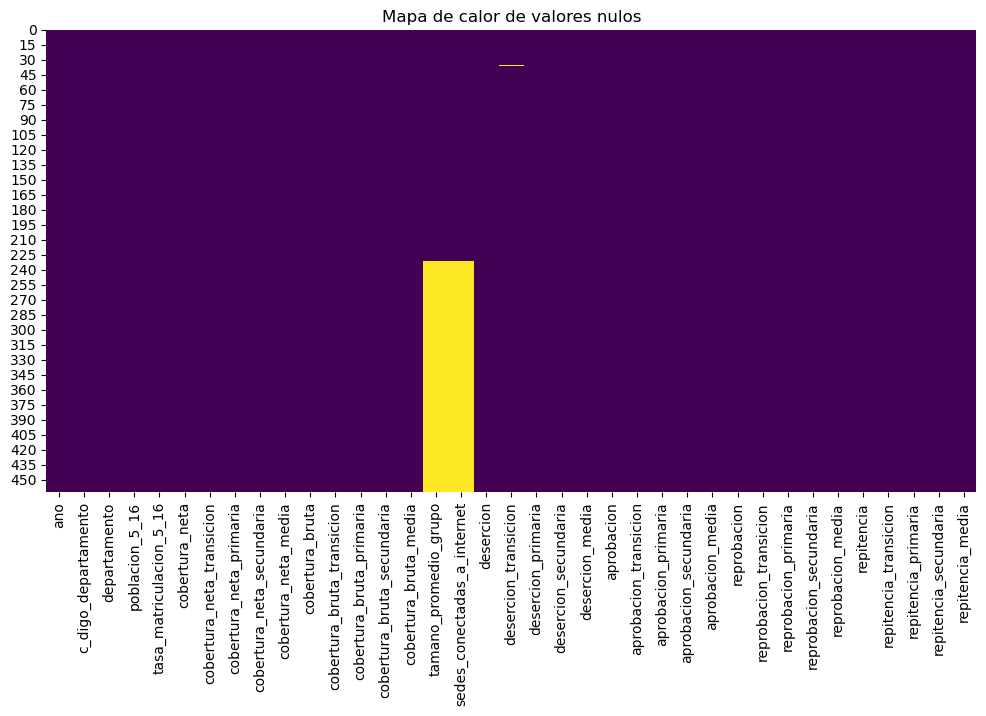

In [6]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Mapa de calor de valores nulos')
plt.show()

In [7]:
df.describe()

,ano,c_digo_departamento,poblacion_5_16,tasa_matriculacion_5_16,cobertura_neta,cobertura_neta_transicion,cobertura_neta_primaria,cobertura_neta_secundaria,cobertura_neta_media,cobertura_bruta,...,reprobacion,reprobacion_transicion,reprobacion_primaria,reprobacion_secundaria,reprobacion_media,repitencia,repitencia_transicion,repitencia_primaria,repitencia_secundaria,repitencia_media
count,462.000000,462.000000,4.620000e+02,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,...,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000
mean,2017.500000,52.151515,3.004250e+05,85.531212,85.847597,57.632424,84.146429,68.276580,38.662879,98.107792,...,5.892143,1.474221,91.563095,8.281926,5.225043,4.314307,1.474221,4.203506,5.613333,2.257987
std,4.035499,30.824090,3.098399e+05,10.407188,10.468299,11.533466,9.982955,15.290438,12.813470,11.308172,...,3.633245,2.384782,4.675163,4.709547,2.842663,3.429386,2.384782,3.849724,4.127737,1.768956
min,2011.000000,5.000000,1.072600e+04,52.330000,50.790000,19.220000,51.120000,24.060000,6.790000,59.790000,...,0.000000,0.000000,70.720000,0.000000,0.000000,0.100000,0.000000,0.060000,0.110000,0.000000
25%,2014.000000,20.000000,8.702850e+04,79.925000,80.607500,51.300000,78.417500,60.895000,30.450000,93.167500,...,3.260000,0.212500,90.242500,4.462500,3.320000,1.605000,0.212500,1.350000,2.067500,0.892500
50%,2017.500000,52.000000,2.344540e+05,87.435000,88.190000,58.800000,86.200000,72.710000,41.200000,100.220000,...,6.150000,0.580000,92.120000,9.180000,5.325000,3.230000,0.580000,2.940000,4.265000,1.685000
75%,2021.000000,81.000000,3.886455e+05,93.445000,93.430000,66.147500,91.332500,78.812500,48.090000,105.487500,...,7.667500,1.590000,94.450000,11.480000,6.667500,6.405000,1.590000,6.067500,8.702500,3.490000
max,2024.000000,99.000000,1.479334e+06,103.940000,103.880000,88.280000,102.760000,91.090000,65.320000,123.040000,...,19.320000,17.010000,99.060000,24.570000,17.910000,17.370000,17.010000,22.770000,25.220000,16.390000
